<a href="https://colab.research.google.com/github/asmitwankhedee/CODSOFT_DataScience/blob/main/Movie_Rating_Prediction_Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import required Libraries

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Import Dataset through Kaggle API

In [81]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adrianmcmahon/imdb-india-movies")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'imdb-india-movies' dataset.
Path to dataset files: /kaggle/input/imdb-india-movies


In [82]:
import os

Getting Dataset Path

In [83]:
os.listdir(path)

['IMDb Movies India.csv']

In [84]:
df=pd.read_csv(path+'/IMDb Movies India.csv',encoding='latin1')

In [85]:
df

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
...,...,...,...,...,...,...,...,...,...,...
15504,Zulm Ko Jala Doonga,(1988),NaN,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN


Finding Shape

In [86]:
df.shape

(15509, 10)

Finding Size

In [87]:
df.size

155090

Checking Distribution

In [88]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


Checking Datatypes

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


Checking Columns Name

In [90]:
df.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

Checking Null Values

In [91]:
df.isnull().sum()

,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


Check Duplicated Values

In [92]:
df.duplicated().sum()

np.int64(6)

Droping Duplicated values

In [93]:
df=df.drop_duplicates()

Rechecking Duplicated values

In [94]:
df.duplicated().sum()

np.int64(0)

Check Unique values in Name columns using list

In [95]:
df['Name'].unique()

array([' ', '#Gadhvi (He thought he was Gandhi)', '#Homecoming', ...,
       'Zulmi Raj', 'Zulmi Shikari', 'Zulm-O-Sitam'], dtype=object)

Droping Name column

In [96]:
df=df.drop(columns=['Name'],axis=1)

Checking Unique value in Year column

In [97]:
df['Year'].unique()

array([nan, '(2019)', '(2021)', '(2010)', '(1997)', '(2005)', '(2008)',
       '(2012)', '(2014)', '(2004)', '(2016)', '(1991)', '(1990)',
       '(2018)', '(1987)', '(1948)', '(1958)', '(2017)', '(2020)',
       '(2009)', '(2002)', '(1993)', '(1946)', '(1994)', '(2007)',
       '(2013)', '(2003)', '(1998)', '(1979)', '(1951)', '(1956)',
       '(1974)', '(2015)', '(2006)', '(1981)', '(1985)', '(2011)',
       '(2001)', '(1967)', '(1988)', '(1995)', '(1959)', '(1996)',
       '(1970)', '(1976)', '(2000)', '(1999)', '(1973)', '(1968)',
       '(1943)', '(1953)', '(1986)', '(1983)', '(1989)', '(1982)',
       '(1977)', '(1957)', '(1950)', '(1992)', '(1969)', '(1975)',
       '(1947)', '(1972)', '(1971)', '(1935)', '(1978)', '(1960)',
       '(1944)', '(1963)', '(1940)', '(1984)', '(1934)', '(1955)',
       '(1936)', '(1980)', '(1966)', '(1949)', '(1962)', '(1964)',
       '(1952)', '(1933)', '(1942)', '(1939)', '(1954)', '(1945)',
       '(1961)', '(1965)', '(1938)', '(1941)', '(1931)', 

Remove '(' and ')' brackets from years columns using lambda function

In [98]:
df['Year']=df['Year'].apply(lambda x: str(x).replace('(','').replace(')','') if '(' in str(x) and ')' in str(x) else x)

Checking unique in  Year column after removing

In [99]:
df['Year'].unique()

array([nan, '2019', '2021', '2010', '1997', '2005', '2008', '2012',
       '2014', '2004', '2016', '1991', '1990', '2018', '1987', '1948',
       '1958', '2017', '2020', '2009', '2002', '1993', '1946', '1994',
       '2007', '2013', '2003', '1998', '1979', '1951', '1956', '1974',
       '2015', '2006', '1981', '1985', '2011', '2001', '1967', '1988',
       '1995', '1959', '1996', '1970', '1976', '2000', '1999', '1973',
       '1968', '1943', '1953', '1986', '1983', '1989', '1982', '1977',
       '1957', '1950', '1992', '1969', '1975', '1947', '1972', '1971',
       '1935', '1978', '1960', '1944', '1963', '1940', '1984', '1934',
       '1955', '1936', '1980', '1966', '1949', '1962', '1964', '1952',
       '1933', '1942', '1939', '1954', '1945', '1961', '1965', '1938',
       '1941', '1931', '1937', '2022', '1932', '1923', '1915', '1928',
       '1922', '1917', '1913', '1930', '1926', '1914', '1924'],
      dtype=object)

Change Datatype of year column object to numeric

In [100]:
df['Year']=pd.to_numeric(df['Year'],errors='coerce')

Filling Null values of Year columns using bfill and ffill

In [101]:
df['Year']=df['Year'].interpolate().bfill().ffill()

Check Unique values in Duration column

In [102]:
df['Duration'].unique()

array([nan, '109 min', '90 min', '110 min', '105 min', '147 min',
       '142 min', '59 min', '82 min', '116 min', '96 min', '120 min',
       '161 min', '166 min', '102 min', '87 min', '132 min', '66 min',
       '146 min', '112 min', '168 min', '158 min', '126 min', '94 min',
       '138 min', '124 min', '144 min', '157 min', '136 min', '107 min',
       '113 min', '80 min', '122 min', '149 min', '148 min', '130 min',
       '121 min', '188 min', '115 min', '103 min', '114 min', '170 min',
       '100 min', '99 min', '140 min', '128 min', '93 min', '125 min',
       '145 min', '75 min', '111 min', '134 min', '85 min', '104 min',
       '92 min', '137 min', '127 min', '150 min', '119 min', '135 min',
       '86 min', '76 min', '70 min', '72 min', '151 min', '95 min',
       '52 min', '89 min', '143 min', '177 min', '117 min', '123 min',
       '154 min', '88 min', '175 min', '153 min', '78 min', '139 min',
       '133 min', '101 min', '180 min', '60 min', '46 min', '164 min',
       '

Removing 'min' from Duration column

In [103]:
df['Duration']=df['Duration'].apply(lambda x:str(x).replace('min','') if 'min' in str(x) else x)

Chnage Datatype of Duration column

In [104]:
df['Duration']=pd.to_numeric(df['Duration'],errors='coerce')

In [105]:
df['Duration'].unique()

array([ nan, 109.,  90., 110., 105., 147., 142.,  59.,  82., 116.,  96.,
       120., 161., 166., 102.,  87., 132.,  66., 146., 112., 168., 158.,
       126.,  94., 138., 124., 144., 157., 136., 107., 113.,  80., 122.,
       149., 148., 130., 121., 188., 115., 103., 114., 170., 100.,  99.,
       140., 128.,  93., 125., 145.,  75., 111., 134.,  85., 104.,  92.,
       137., 127., 150., 119., 135.,  86.,  76.,  70.,  72., 151.,  95.,
        52.,  89., 143., 177., 117., 123., 154.,  88., 175., 153.,  78.,
       139., 133., 101., 180.,  60.,  46., 164., 162., 171., 160., 152.,
        62., 163., 165., 141., 210., 129., 156., 240., 172., 155., 118.,
       167., 106., 193.,  57., 108.,  45., 195., 174.,  81., 178.,  58.,
       184.,  97.,  98., 131., 176., 169.,  77.,  91.,  84., 173.,  74.,
        67., 181., 300.,  79.,  65.,  48., 183., 159.,  83.,  68.,  49.,
       201.,  64., 186.,  50.,  69., 207.,  55.,  61., 185., 187., 216.,
        63.,  54., 198.,  51.,  71.,  73., 218., 19

In [106]:
df['Duration'].dtype

dtype('float64')

Filling Null values of Duration with median

In [107]:
df['Duration'].median()

131.0

In [108]:
df['Duration']=df['Duration'].fillna(df['Duration'].median())

In [109]:
df['Genre'].unique()

array(['Drama', 'Drama, Musical', 'Comedy, Romance',
       'Comedy, Drama, Musical', 'Drama, Romance, War', 'Documentary',
       'Horror, Mystery, Thriller', 'Action, Crime, Thriller', 'Horror',
       'Horror, Romance, Thriller', 'Comedy, Drama, Romance', 'Thriller',
       'Comedy, Drama', nan, 'Comedy, Drama, Fantasy',
       'Comedy, Drama, Family', 'Crime, Drama, Mystery',
       'Horror, Thriller', 'Biography', 'Comedy, Horror', 'Action',
       'Drama, Horror, Mystery', 'Comedy', 'Action, Thriller',
       'Drama, History', 'Drama, History, Sport',
       'Horror, Mystery, Romance', 'Horror, Mystery',
       'Drama, Horror, Romance', 'Action, Drama, History',
       'Action, Drama, War', 'Comedy, Family',
       'Adventure, Horror, Mystery', 'Action, Sci-Fi',
       'Crime, Mystery, Thriller', 'War', 'Sport',
       'Biography, Drama, History', 'Horror, Romance', 'Crime, Drama',
       'Drama, Romance', 'Adventure, Drama', 'Comedy, Mystery, Thriller',
       'Action, Crime, Dr

Filling Null values of Genere column with 'Unknown' value because we dont put randomly genere of any movie using mode.

In [110]:
df['Genre'] = df['Genre'].fillna("Unknown")
df['Genre'] = df['Genre'].str.split(", ")
df = df.explode('Genre')

In [111]:
df['Genre'].explode('Genre')

,Genre
0,Drama
1,Drama
2,Drama
3,Musical
4,Comedy
...,...
24939,Drama
24940,Action
24941,Action
24942,Action


In [112]:
df['Votes'].unique()

array([nan, '8', '35', ..., '70,344', '408', '1,496'], dtype=object)

Checking Unique values in

In [113]:
df['Votes'].unique()

array([nan, '8', '35', ..., '70,344', '408', '1,496'], dtype=object)

Change datatype of Votes column

In [114]:
df['Votes']=pd.to_numeric(df['Votes'],errors='coerce')

In [115]:
df['Votes'].dtypes

dtype('float64')

Filling null values of votes column with mean

In [116]:
df['Votes'].median()

45.0

In [117]:
df['Votes']=df['Votes'].fillna(df['Votes'].mean())

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24944 entries, 0 to 15508
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Year      24944 non-null  float64
 1   Duration  24944 non-null  float64
 2   Genre     24944 non-null  object 
 3   Rating    15837 non-null  float64
 4   Votes     24944 non-null  float64
 5   Director  24403 non-null  object 
 6   Actor 1   23163 non-null  object 
 7   Actor 2   22274 non-null  object 
 8   Actor 3   21423 non-null  object 
dtypes: float64(4), object(5)
memory usage: 1.9+ MB


Filling Null values of rating column with median

In [119]:
df['Rating']=df['Rating'].fillna(df['Rating'].median())

In [120]:
df['Director'].unique()

array(['J.S. Randhawa', 'Gaurav Bakshi', 'Soumyajit Majumdar', ...,
       'Mozez Singh', 'Ved Prakash', 'Kiran Thej'], dtype=object)

Filling Null Values of director column with 'Unknown'

In [121]:
df['Director']=df['Director'].fillna("Unknown")

In [122]:
!pip install category_encoders

In [123]:
from category_encoders import TargetEncoder

cols = ["Genre", "Director", "Actor 1", "Actor 2", "Actor 3"]

encoder = TargetEncoder(cols=cols)
df[cols] = encoder.fit_transform(df[cols], df["Rating"])

In [124]:
df["Actor_Count"] = df[["Actor 1","Actor 2","Actor 3"]].notnull().sum(axis=1)

df.drop(columns=["Actor 1","Actor 2","Actor 3"], inplace=True)

Checking Null Values after removing

In [125]:
df.isnull().sum()

,0
Year,0
Duration,0
Genre,0
Rating,0
Votes,0
Director,0
Actor_Count,0


In [126]:
df_col=df.select_dtypes(exclude='object')

In [127]:
df_col

,Year,Duration,Genre,Rating,Votes,Director,Actor_Count
0,2019.0,131.0,5.999020,6.0,142.855324,5.882955,3
1,2019.0,109.0,5.999020,7.0,8.000000,6.033030,3
2,2021.0,90.0,5.999020,6.0,142.855324,5.904232,3
2,2021.0,90.0,6.132428,6.0,142.855324,5.904232,3
3,2019.0,110.0,5.791671,4.4,35.000000,5.677271,3
...,...,...,...,...,...,...,...
15505,1999.0,129.0,5.999020,4.5,655.000000,5.602105,3
15506,2005.0,131.0,5.620779,6.0,142.855324,5.902922,3
15507,1988.0,131.0,5.620779,6.0,142.855324,6.009982,3
15508,1998.0,130.0,5.620779,6.2,20.000000,4.459826,3


Checking Outliers using Boxplot

<Axes: >

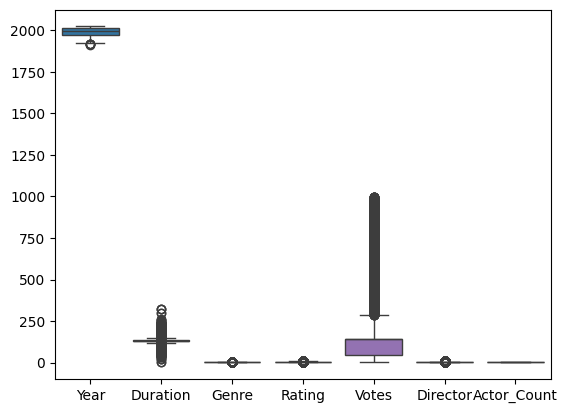

In [128]:
sns.boxplot(df)

Checking Distribution

/tmp/ipykernel_18442/2160066058.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Rating'])


<Axes: xlabel='Rating', ylabel='Density'>

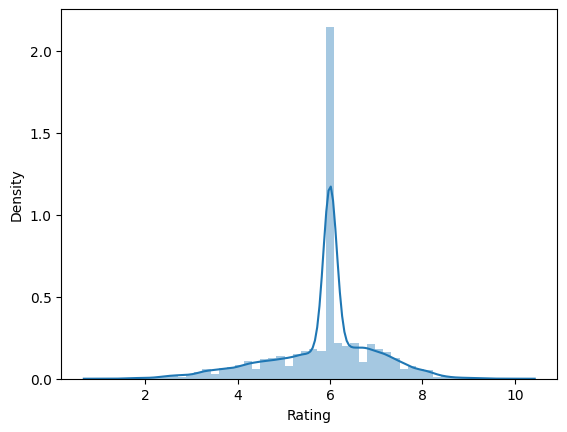

In [129]:
sns.distplot(df['Rating'])

Checking Distribution

/tmp/ipykernel_18442/24221160.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Votes'])


<Axes: xlabel='Votes', ylabel='Density'>

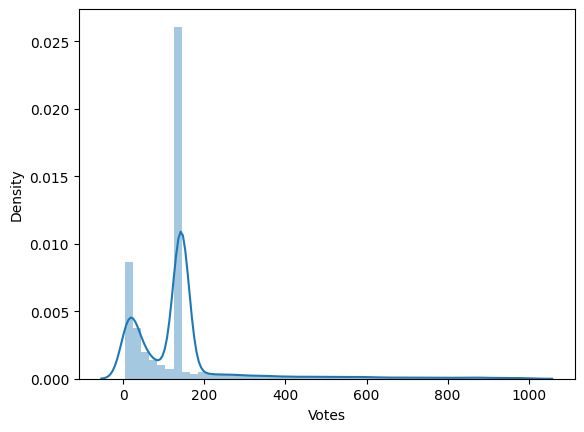

In [130]:
sns.distplot(df['Votes'])

Checking Outliers in votes column

<Axes: ylabel='Votes'>

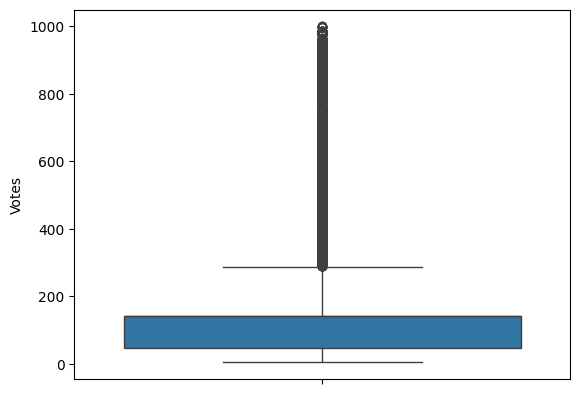

In [131]:
sns.boxplot(df['Votes'])

In [132]:
Q1=df['Votes'].quantile(0.25)
Q2=df['Votes'].quantile(0.50)
Q3=df['Votes'].quantile(0.75)
print(Q1)
print(Q2)
print(Q3)

46.0
142.85532398021246
142.85532398021246


Finding Inter Quantile range

In [133]:
IQR=Q3-Q1
print(IQR)

96.85532398021246


Check Upper and Lower Limit

In [134]:
upper_limit=Q3+1.5*IQR
lower_limit=Q1-1.5*IQR
print(upper_limit)
print(lower_limit)

288.13830995053115
-99.28298597031869


Using Bowley Method to check Skweness

In [135]:
Bowley_votes=(Q3+Q1-2*Q2)/(Q3-Q1)
print(Bowley_votes)

-1.0


Transform votes column using Log1p

In [136]:
df['Votes']=np.log1p(df['Votes'])

<Axes: ylabel='Votes'>

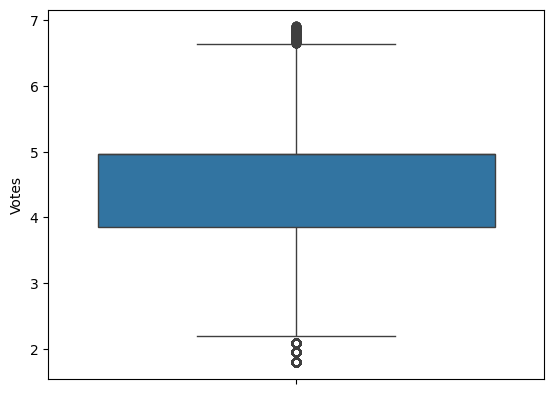

In [137]:
sns.boxplot(df['Votes'])

Text(0.5, 1.0, 'Votes vs Movie Rating')

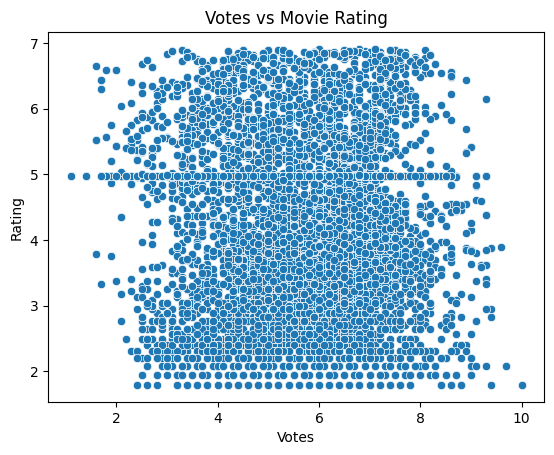

In [138]:
sns.scatterplot(x=df['Rating'],y=df['Votes'])
plt.xlabel("Votes")
plt.ylabel("Rating")
plt.title("Votes vs Movie Rating")

Features Selection

In [139]:
features = df[["Genre","Director","Votes", "Year", "Duration", 'Rating']]

In [140]:
X=features.drop('Rating',axis=1)
y=features['Rating']

import Library

In [141]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

Divide data into 80% train and 20% for test

In [142]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

Using Random Forest Regressor

In [143]:
model=RandomForestRegressor()

In [144]:
model.fit(X_train,y_train)

RandomForestRegressor()

In [145]:
y_pred=model.predict(X_test)

In [146]:
y_pred

array([5.703, 6.008, 5.841, ..., 6.   , 6.   , 6.   ])

Regresion Plot for showing data are in linear

<Axes: xlabel='Rating'>

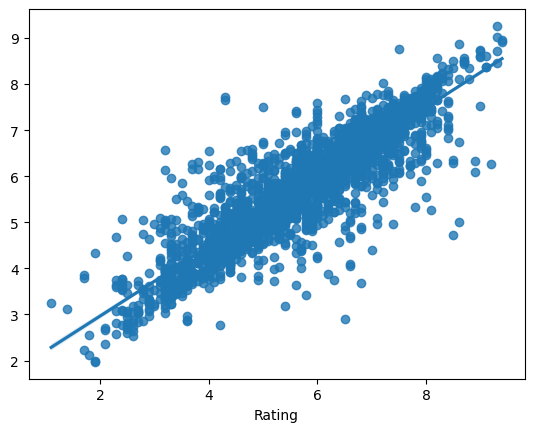

In [147]:
sns.regplot(x=y_test,y=y_pred)

Checking Accuracy using R2 score

In [148]:
print(r2_score(y_test,y_pred))

0.7943121972975408


Model Accuracy is 79%